# 10.2 Similarity and Distance in Data Analysis

In this notebook, we examine why similarity measurement is useful in a real data analysis task.

Our main question will be:

> If we select one observation, which other observations are most similar to it?

This idea is the basis of many practical tasks:
- finding similar observations,
- identifying anomalies,
- understanding local structure in the data.


## Loading the Iris dataset

The Iris dataset is a classic teaching dataset. It contains 4 numerical features for each flower and describes samples belonging to 3 species:
- Setosa
- Versicolor
- Virginica

It is a good starting point because:
- it is small and easy to inspect,
- it contains numerical variables,
- and the group structure is clearly visible.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA

In [2]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris sample dataset
iris = load_iris()

# Convert the data into a DataFrame
# The column names will be the original feature names
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the species identifier
df["species_id"] = iris.target

# Convert numeric species identifiers into textual species names
df["species"] = df["species_id"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Print the shape of the DataFrame
print("DataFrame shape:", df.shape)

# Display the first few rows
display(df.head())


DataFrame shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [3]:
df["species"].value_counts()

,count
species,
Setosa,50
Versicolor,50
Virginica,50


## First visual overview

To begin, let's look at two variables. This does not yet show the full 4-dimensional similarity, but it helps us get a feel for the structure of the data.


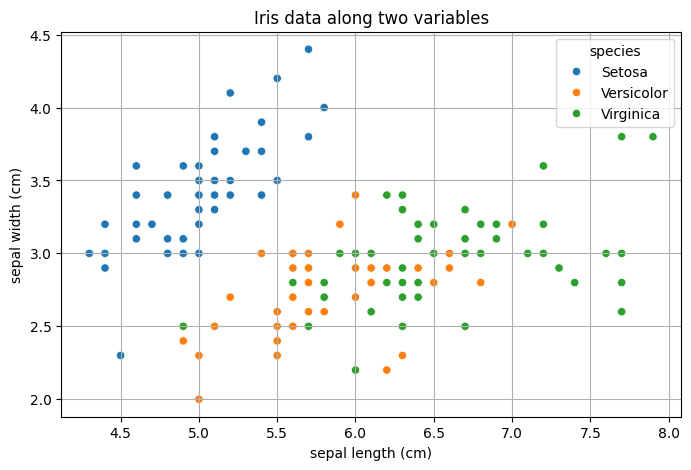

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the figure with the given size
plt.figure(figsize=(8, 5))

# Create a scatter plot using two variables
# The color of the points indicates the species
sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species"
)

# Add title
plt.title("Iris data along two variables")

# Turn on grid lines for better readability
plt.grid(True)

# Show the figure
plt.show()


## Distance and scaling

We will now use Euclidean distance. In this case, it is worth standardizing the variables so that no single variable dominates the distance calculation too strongly.

After standardization, every variable is placed on a more comparable scale.


In [5]:
from sklearn.preprocessing import StandardScaler

# Select the columns used for distance calculations
feature_cols = iris.feature_names

# Create the scaler object
scaler = StandardScaler()

# Scale the numerical features
# This makes variables measured in different units more comparable
X_scaled = scaler.fit_transform(df[feature_cols])

# Convert the scaled data back into a DataFrame
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

# Add species names back to the scaled DataFrame
df_scaled["species"] = df["species"]

# Add numeric species identifiers back to the scaled DataFrame
df_scaled["species_id"] = df["species_id"]

# Display the first few rows
display(df_scaled.head().round(3))


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_id
0,-0.901,1.019,-1.340,-1.315,Setosa,0
1,-1.143,-0.132,-1.340,-1.315,Setosa,0
2,-1.385,0.328,-1.397,-1.315,Setosa,0
3,-1.507,0.098,-1.283,-1.315,Setosa,0
4,-1.022,1.249,-1.340,-1.315,Setosa,0


## The nearest neighbors of a selected sample

Let's choose a specific flower and calculate its distance from all other samples.

We will now select row 75, which is a **Versicolor** sample.


In [6]:
# Index of the sample we compare to the other observations
query_index = 75

# Extract the original (unscaled) features of the selected sample
query_raw = df.loc[query_index, feature_cols]

# Extract the scaled features of the selected sample
query_scaled = X_scaled[query_index]

# Print the index of the selected sample
print("Selected sample index:", query_index)

# Display the original features of the selected sample
display(query_raw.to_frame(name="value"))

# Print the species of the selected sample
print("Species:", df.loc[query_index, "species"])


Selected sample index: 75


,value
sepal length (cm),6.6
sepal width (cm),3.0
petal length (cm),4.4
petal width (cm),1.4


Species: Versicolor


In [7]:
import math

# We collect the distance of each sample in this list
distances = []

# Go through all scaled samples
for i in range(len(X_scaled)):
    current_point = X_scaled[i]

    squared_sum = 0

    # Compute the Euclidean distance from the selected sample
    for a, b in zip(current_point, query_scaled):
        squared_sum += (a - b) ** 2

    distance = math.sqrt(squared_sum)

    # Save the index and distance
    distances.append({
        "index": i,
        "distance_from_query": distance
    })

# Build a DataFrame from the list of distances
distances_df = pd.DataFrame(distances)
distances_df


,index,distance_from_query
0,0,3.167124
1,1,3.105726
2,2,3.333412
3,3,3.337303
4,4,3.326965
...,...,...
145,145,1.274725
146,146,1.416465
147,147,0.919351
148,148,1.676095


In [8]:
# Attach the distances to a copy of the original DataFrame
neighbors_df = df.copy()
neighbors_df["distance_from_query"] = distances_df["distance_from_query"]
neighbors_df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species,distance_from_query
0,5.1,3.5,1.4,0.2,0,Setosa,3.167124
1,4.9,3.0,1.4,0.2,0,Setosa,3.105726
2,4.7,3.2,1.3,0.2,0,Setosa,3.333412
3,4.6,3.1,1.5,0.2,0,Setosa,3.337303
4,5.0,3.6,1.4,0.2,0,Setosa,3.326965
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,Virginica,1.274725
146,6.3,2.5,5.0,1.9,2,Virginica,1.416465
147,6.5,3.0,5.2,2.0,2,Virginica,0.919351
148,6.2,3.4,5.4,2.3,2,Virginica,1.676095


In [9]:
# Find the 5 nearest neighbors
# The first row will be the selected sample itself, so we skip it
closest_neighbors = (
    neighbors_df
    .sort_values("distance_from_query")
    .iloc[1:6]
    [[*feature_cols, "species", "distance_from_query"]]
)

closest_neighbors.round(3)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,distance_from_query
65,6.7,3.1,4.4,1.4,Versicolor,0.260
58,6.6,2.9,4.6,1.3,Versicolor,0.289
86,6.7,3.1,4.7,1.5,Versicolor,0.338
74,6.4,2.9,4.3,1.3,Versicolor,0.364
54,6.5,2.8,4.6,1.5,Versicolor,0.507


**What do we see?**

We identified the 5 nearest other samples to the selected observation. If most of them belong to the same species, that suggests the observation lies within its own group.

This idea is very important because many analysis and modeling tasks rely on:
- who the nearest neighbors are,
- what the local neighborhood looks like,
- and how "typical" a given point is.


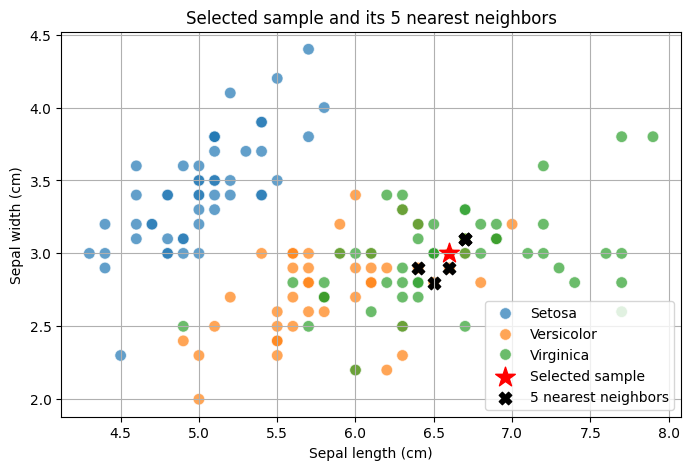

In [10]:
# Collect the indices of the 5 nearest neighbors
neighbor_indices = closest_neighbors.index.tolist()

# Create the figure
plt.figure(figsize=(8, 5))

# Plot all points using the first two variables
sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species",
    s=70,
    alpha=0.7
)

# Highlight the selected sample
query_point = df.loc[query_index]
plt.scatter(
    query_point["sepal length (cm)"],
    query_point["sepal width (cm)"],
    color="red",
    marker="*",
    s=220,
    label="Selected sample"
)

# Highlight the 5 nearest neighbors
neighbors_points = df.loc[neighbor_indices]
plt.scatter(
    neighbors_points["sepal length (cm)"],
    neighbors_points["sepal width (cm)"],
    color="black",
    marker="X",
    s=80,
    label="5 nearest neighbors"
)

# Title and axis labels
plt.title("Selected sample and its 5 nearest neighbors")
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")

# Grid and legend
plt.grid(True)
plt.legend()

# Show the figure
plt.show()


## We are not limited to one sample

Similarity measurement tells us not only which points are close to a given observation, but also which points lie in a more unusual neighborhood.

To do this, we compute the distance to the nearest other neighbor for every sample. If this value is large, then the point is less typical in its local environment.


In [11]:
import math

# We collect the nearest-neighbor distance of each sample in this list
nearest_neighbor_distances = []

# Go through all samples
for i in range(len(X_scaled)):
    distances = []

    # Compare sample i to all others
    for j in range(len(X_scaled)):
        if i != j:  # Skip the sample itself
            squared_sum = 0

            for a, b in zip(X_scaled[i], X_scaled[j]):
                squared_sum += (a - b) ** 2

            distance = math.sqrt(squared_sum)
            distances.append(distance)

    # Select the minimum distance
    nearest_neighbor_distances.append(min(distances))

nearest_neighbor_distances[:10]


[0.13163218429030077,
 0.16614338753163216,
 0.13383626536185467,
 0.23710977266679076,
 0.1789097112201713,
 0.22734970765441265,
 0.29828780673213984,
 0.12116787044365074,
 0.23710977266679076,
 0.13163218429030077]

In [12]:
# Add the nearest-neighbor distance to the original DataFrame
nn_df = df.copy()
nn_df["nearest_neighbor_distance"] = nearest_neighbor_distances

# See which samples are farthest from their own nearest neighbor
nn_df.sort_values("nearest_neighbor_distance", ascending=False).head(10)[
    [*feature_cols, "species", "nearest_neighbor_distance"]
].round(3)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,nearest_neighbor_distance
41,4.5,2.3,1.3,0.3,Setosa,1.394
109,7.2,3.6,6.1,2.5,Virginica,0.923
106,4.9,2.5,4.5,1.7,Virginica,0.785
60,5.0,2.0,3.5,1.0,Versicolor,0.700
108,6.7,2.5,5.8,1.8,Virginica,0.665
62,6.0,2.2,4.0,1.0,Versicolor,0.627
118,7.7,2.6,6.9,2.3,Virginica,0.617
114,5.8,2.8,5.1,2.4,Virginica,0.591
15,5.7,4.4,1.5,0.4,Setosa,0.586
14,5.8,4.0,1.2,0.2,Setosa,0.570


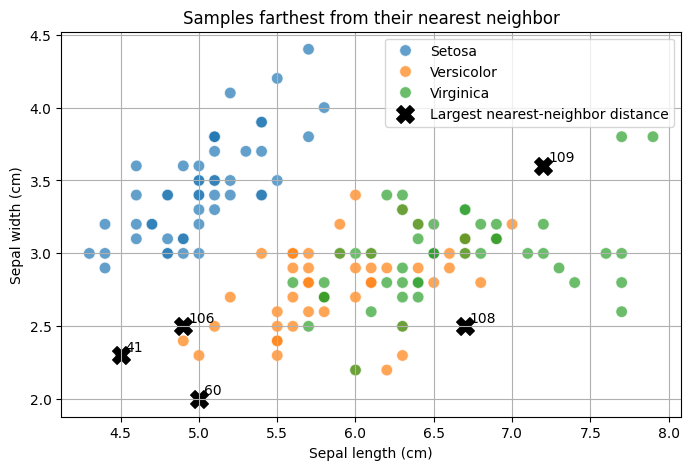

In [13]:
# Select the 5 samples with the largest nearest-neighbor distance
top_far_points = nn_df.sort_values("nearest_neighbor_distance", ascending=False).head(5)

# Create the figure
plt.figure(figsize=(8, 5))

# Plot all points
sns.scatterplot(
    data=nn_df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species",
    s=70,
    alpha=0.7
)

# Highlight the most isolated points
plt.scatter(
    top_far_points["sepal length (cm)"],
    top_far_points["sepal width (cm)"],
    color="black",
    marker="X",
    s=160,
    label="Largest nearest-neighbor distance"
)

# Print the indices of the highlighted points
for idx in top_far_points.index:
    plt.text(
        nn_df.loc[idx, "sepal length (cm)"] + 0.03,
        nn_df.loc[idx, "sepal width (cm)"] + 0.03,
        str(idx)
    )

# Title and axis labels
plt.title("Samples farthest from their nearest neighbor")
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")

# Grid and legend
plt.grid(True)
plt.legend()

# Show the figure
plt.show()


**Interpretation:**

Samples whose nearest neighbor is still relatively far away:
- may be borderline cases,
- may be less typical observations,
- or may even be potential anomalies.

This is already a real data analysis idea, because we want to understand the structure of the data.


## Interpreting the more unusual samples

In the previous step, we identified the samples that are relatively far even from their nearest neighbor.

However, this alone does not yet explain **why** they are unusual.

The following figures help us investigate whether these samples:
- differ from the other observations along specific variables,
- are unusual within a given species,
- or stand out relative to the full dataset.


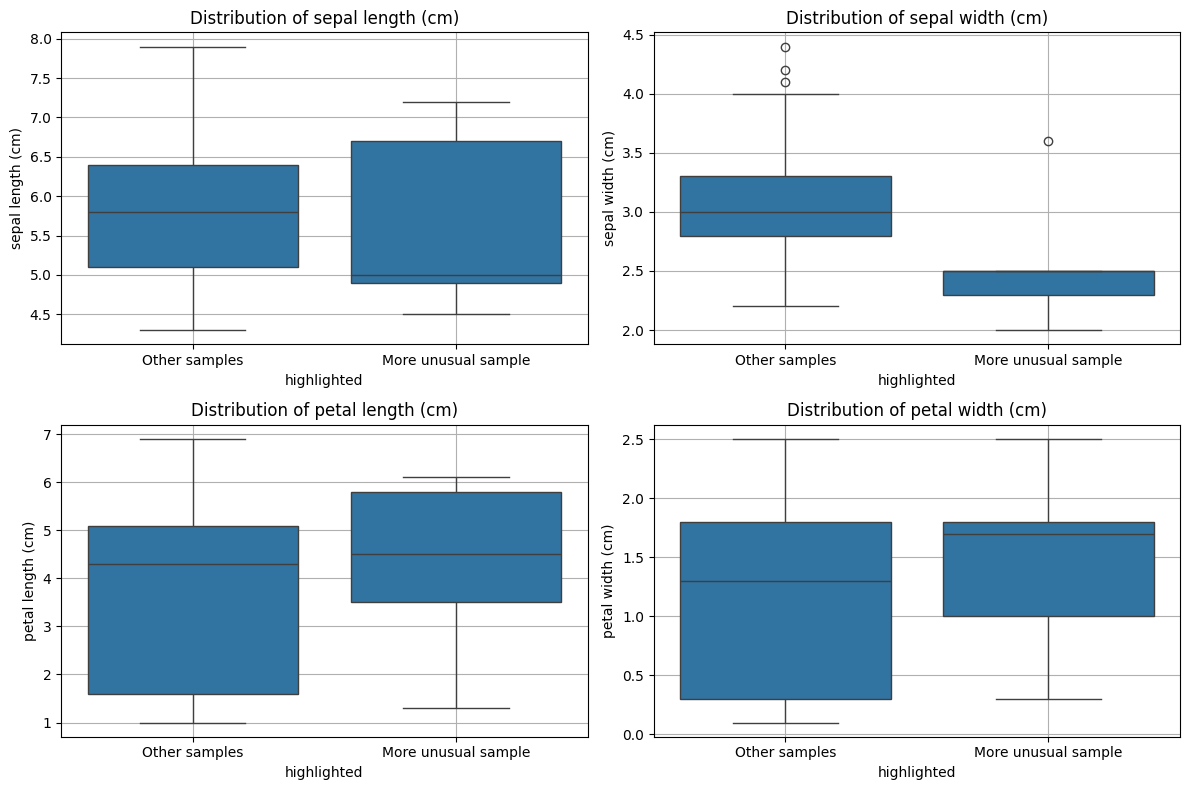

In [14]:
# Indices of the 5 most isolated samples
top_indices = top_far_points.index.tolist()

# Create a copy so we can mark the highlighted points
box_df = df.copy()
box_df["highlighted"] = "Other samples"
box_df.loc[top_indices, "highlighted"] = "More unusual sample"

# Inspect the four numerical variables with boxplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=box_df, x="highlighted", y=col, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].grid(True)

plt.tight_layout()
plt.show()


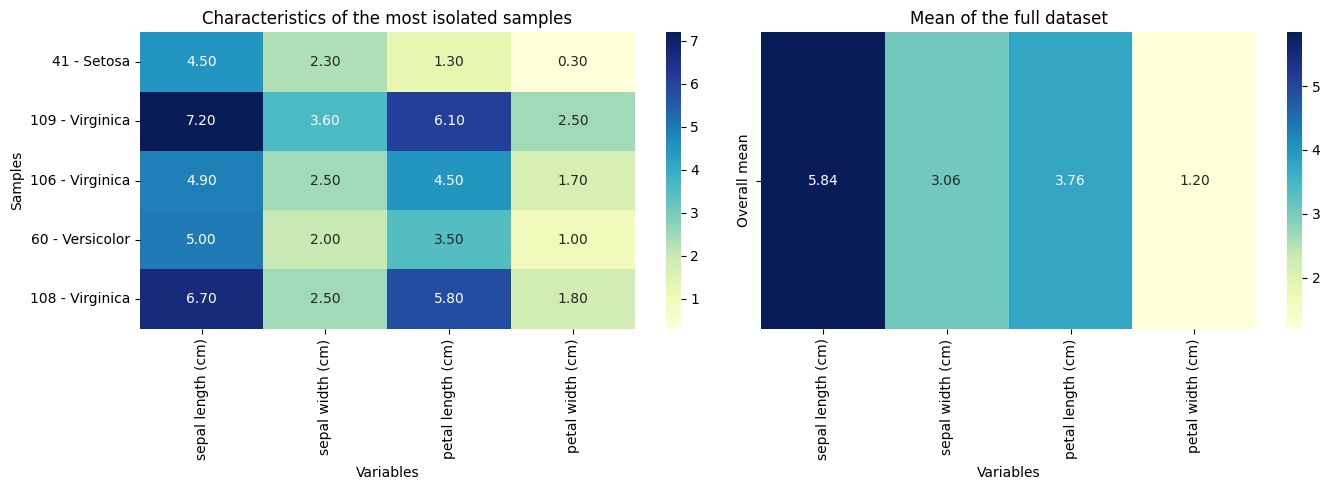

In [15]:
# Select the numerical features of the highlighted samples
special_points_df = df.loc[top_indices, feature_cols + ["species"]].copy()

# Prepare row labels
row_labels = [
    f"{idx} - {species}"
    for idx, species in zip(special_points_df.index, special_points_df["species"])
]

# Select only the numerical columns for the highlighted samples
special_points_numeric = special_points_df[feature_cols]

# Compute the average of the full dataset
mean_df = pd.DataFrame(df[feature_cols].mean()).T
mean_df.index = ["Overall mean"]

# Create two side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap for the highlighted samples
sns.heatmap(
    special_points_numeric,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    yticklabels=row_labels,
    ax=axes[0]
)
axes[0].set_title("Characteristics of the most isolated samples")
axes[0].set_xlabel("Variables")
axes[0].set_ylabel("Samples")

# Heatmap for the overall mean
sns.heatmap(
    mean_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    ax=axes[1]
)
axes[1].set_title("Mean of the full dataset")
axes[1].set_xlabel("Variables")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## Comparing the unusual samples with the average

The figures below help us understand how the previously highlighted samples differ from the typical values of the dataset.

On the left, we see the characteristics of the most isolated samples; on the right, the average values of the full dataset.


## Exercises


### On the Palmer Penguins dataset

In the following exercises, we work with the Palmer Penguins dataset.

The dataset contains measurement data for different penguins, such as bill length, bill depth, flipper length, and body mass.

This dataset is useful for practicing similarity measurement because:
- it contains several numerical variables,
- the individual observations can be compared meaningfully,
- and it includes natural group structure.


In [16]:
import pandas as pd
import seaborn as sns

# Load the Palmer Penguins dataset
df = sns.load_dataset("penguins")

# Keep only the most important columns
df = df[[
    "species",
    "island",
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]

# Drop rows containing missing values
df = df.dropna().reset_index(drop=True)

print("DataFrame shape:", df.shape)
display(df.head())


DataFrame shape: (342, 6)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0


### Exercise 1 - Exploring the dataset
Examine the structure of the dataset.
- How many rows and columns does it have?
- Which columns are numerical?
- What species are included?


In [22]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.spatial import distance
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = sns.load_dataset("penguins")
df = df[["species","island","bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]]
df = df.dropna().reset_index(drop=True)

# Load the Palmer Penguins dataset
df = sns.load_dataset("penguins")

# Keep only the most important columns
df = df[[
    "species",
    "island",
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]

# Drop rows containing missing values
df = df.dropna().reset_index(drop=True)

print("DataFrame shape:", df.shape)
display(df.head())


print("Exercise 1 - Dataset structure")
print("Shape:", df.shape)
print("Numerical columns:", df.select_dtypes(include=np.number).columns.tolist())
print("Species included:", df["species"].unique())
display(df.head())

numerical_cols = ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]
penguin1 = df.iloc[0][numerical_cols]
penguin2 = df.iloc[1][numerical_cols]

DataFrame shape: (342, 6)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0


Exercise 1 - Dataset structure
Shape: (342, 6)
Numerical columns: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Species included: ['Adelie' 'Chinstrap' 'Gentoo']


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0


### Exercise 2 - Distance between two selected penguins
Select two penguins from the dataset and compute the Euclidean distance between them based on the numerical variables.
- Then interpret the result.


In [23]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.spatial import distance
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = sns.load_dataset("penguins")
df = df[["species","island","bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]]
df = df.dropna().reset_index(drop=True)
# Load the Palmer Penguins dataset
df = sns.load_dataset("penguins")

# Keep only the most important columns
df = df[[
    "species",
    "island",
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]

# Drop rows containing missing values
df = df.dropna().reset_index(drop=True)

print("\nExercise 2 - Euclidean distance between first two penguins")
dist = distance.euclidean(penguin1, penguin2)
print(dist)

scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(df[numerical_cols])
penguin1_scaled = numerical_scaled[0]
penguin2_scaled = numerical_scaled[1]


Exercise 2 - Euclidean distance between first two penguins
50.26778292306117


### Exercise 3 - Effect of scaling
Standardize the numerical variables, then compute the distance between the same two penguins again.
- Did the result change?
- Why might scaling be important for this dataset?


In [24]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.spatial import distance
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = sns.load_dataset("penguins")
df = df[["species","island","bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]]
df = df.dropna().reset_index(drop=True)
# Load the Palmer Penguins dataset
df = sns.load_dataset("penguins")

# Keep only the most important columns
df = df[[
    "species",
    "island",
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]

# Drop rows containing missing values
df = df.dropna().reset_index(drop=True)

print("\nExercise 3 - Euclidean distance after scaling")
dist_scaled = distance.euclidean(penguin1_scaled, penguin2_scaled)
print(dist_scaled)


Exercise 3 - Euclidean distance after scaling
0.7554550929242262


### Exercise 4 - Finding nearest neighbors
Select one penguin and find the 3 other penguins closest to it based on Euclidean distance.
- Do they belong to the same species?
- Based on which variables might they be similar?


In [25]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.spatial import distance
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = sns.load_dataset("penguins")
df = df[["species","island","bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]]
df = df.dropna().reset_index(drop=True)

# Load the Palmer Penguins dataset
df = sns.load_dataset("penguins")

# Keep only the most important columns
df = df[[
    "species",
    "island",
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]

# Drop rows containing missing values
df = df.dropna().reset_index(drop=True)

print("\nExercise 4 - 3 nearest neighbors for the first penguin")
dist_matrix = distance.squareform(distance.pdist(df[numerical_cols], metric='euclidean'))
nearest_idx = np.argsort(dist_matrix[0])[1:4]
nearest_neighbors = df.iloc[nearest_idx]
display(nearest_neighbors)


Exercise 4 - 3 nearest neighbors for the first penguin


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
148,Adelie,Dream,37.8,18.1,193.0,3750.0
58,Adelie,Biscoe,37.6,19.1,194.0,3750.0
105,Adelie,Biscoe,38.6,17.2,199.0,3750.0


### Exercise 5 - Finding more unusual observations
Compute the distance to the nearest neighbor for every penguin.
- Which penguins have the largest nearest-neighbor distances?
- What might this mean?
- Try to show these observations in a figure as well.



Exercise 5 - Penguins with largest nearest-neighbor distance


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,nearest_distance
300,Gentoo,Biscoe,52.5,15.6,221.0,5450.0,50.048477
339,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,50.097206
252,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,51.698549
189,Chinstrap,Dream,46.9,16.6,192.0,2700.0,150.580543
236,Gentoo,Biscoe,49.2,15.2,221.0,6300.0,250.384504


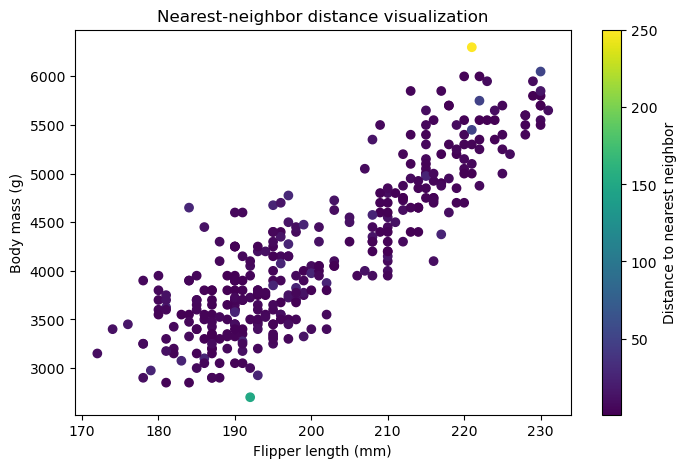

In [26]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.spatial import distance
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = sns.load_dataset("penguins")
df = df[["species","island","bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]]
df = df.dropna().reset_index(drop=True)

# Load the Palmer Penguins dataset
df = sns.load_dataset("penguins")

# Keep only the most important columns
df = df[[
    "species",
    "island",
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]

# Drop rows containing missing values
df = df.dropna().reset_index(drop=True)

print("\nExercise 5 - Penguins with largest nearest-neighbor distance")
nearest_distances = np.sort(dist_matrix, axis=1)[:,1]
df["nearest_distance"] = nearest_distances
largest_nn_idx = np.argsort(nearest_distances)[-5:]
display(df.iloc[largest_nn_idx])

plt.figure(figsize=(8,5))
plt.scatter(df["flipper_length_mm"], df["body_mass_g"], c=df["nearest_distance"], cmap="viridis")
plt.colorbar(label="Distance to nearest neighbor")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.title("Nearest-neighbor distance visualization")
plt.show()